In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats 
from sklearn.linear_model import LinearRegression
import matplotlib.ticker as tick
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import datetime
import string

In [11]:
fp = ("US-Ne1", "US-Ne2", "US-Ne3", "US-Var")

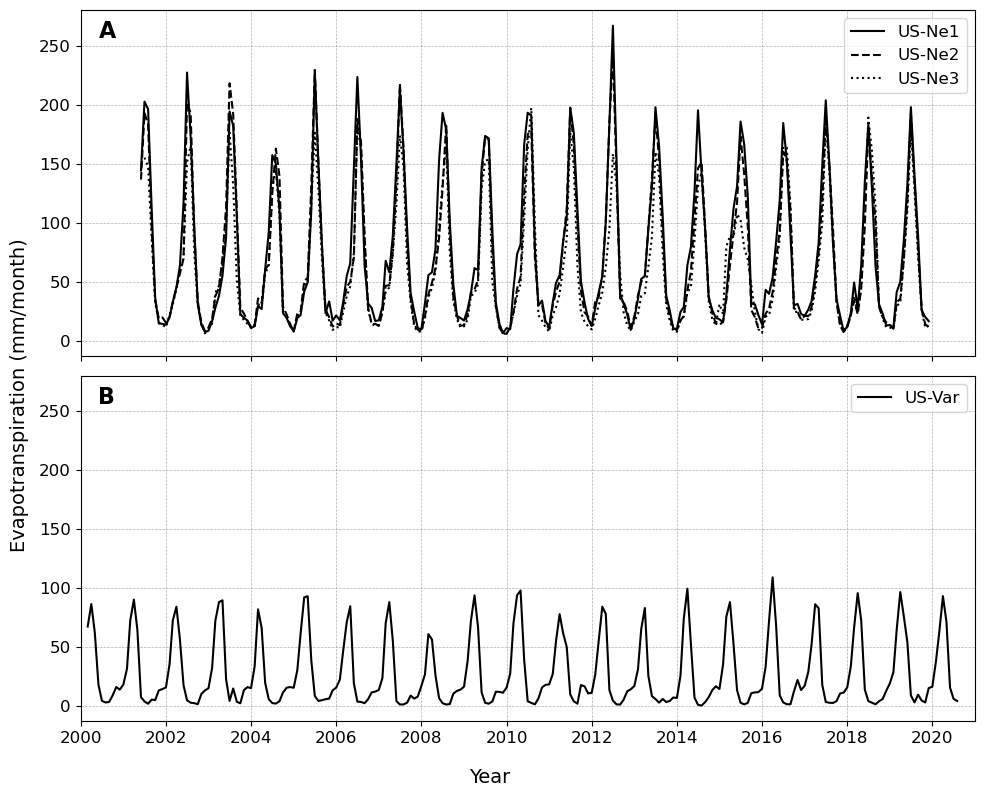

In [12]:
# Create figure with 2 rows, 1 column, shared axes
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)

# Fontsize settings
title_fs = 14
label_fs = 14
tick_fs = 12
legend_fs = 12

# --- Top subplot: US-Ne sites ---
linestyles = ["-", "--", ":"]  # solid, dashed, dotted
for i, fn in enumerate(fp[:3]):
    df = pd.read_csv(fn + "_clim.csv", delimiter=",", parse_dates=["Date"])
    df["Date"] = pd.to_datetime(df["Date"])
    x = df["Date"]

    axes[0].plot(x, df["observed_ET"], linestyle=linestyles[i], color="black", label=fn)

# axes[0].set_title("US-Ne Sites", fontsize=title_fs)
# axes[0].set_ylabel("ET (mm/month)", fontsize=label_fs)
axes[0].legend(fontsize=legend_fs)
axes[0].text(0.02, 0.97, "A", transform=axes[0].transAxes,
             fontsize=16, fontweight="bold", va="top", ha="left")

# --- Bottom subplot: US-Var ---
df = pd.read_csv("US-Var_clim.csv", delimiter=",", parse_dates=["Date"])
df["Date"] = pd.to_datetime(df["Date"])
x = df["Date"]

axes[1].plot(x, df["observed_ET"], color="black", label="US-Var")
# axes[1].set_title("US-Var", fontsize=title_fs)
# axes[1].set_ylabel("ET (mm/month)", fontsize=label_fs)
axes[1].legend(fontsize=legend_fs)
axes[1].text(0.02, 0.97, "B", transform=axes[1].transAxes,
             fontsize=16, fontweight="bold", va="top", ha="left")

# --- Formatting shared axes ---
for ax in axes:
    ax.set_xlim([datetime.date(1999, 12, 31), datetime.date(2021, 1, 1)])
    ax.xaxis.set_major_locator(mdates.YearLocator(4, 1, 7))
    ax.tick_params(axis="both", labelsize=tick_fs)
    # Add light major gridlines
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.grid(True, which="major", linestyle="--", linewidth=0.5, color="gray", alpha=0.6)

fig.supxlabel("Year", fontsize=label_fs)
fig.supylabel("Evapotranspiration (mm/month)", fontsize=label_fs)

fig.tight_layout()
#plt.savefig("FiguresClean/timeseries.pdf", bbox_inches="tight")
plt.show()

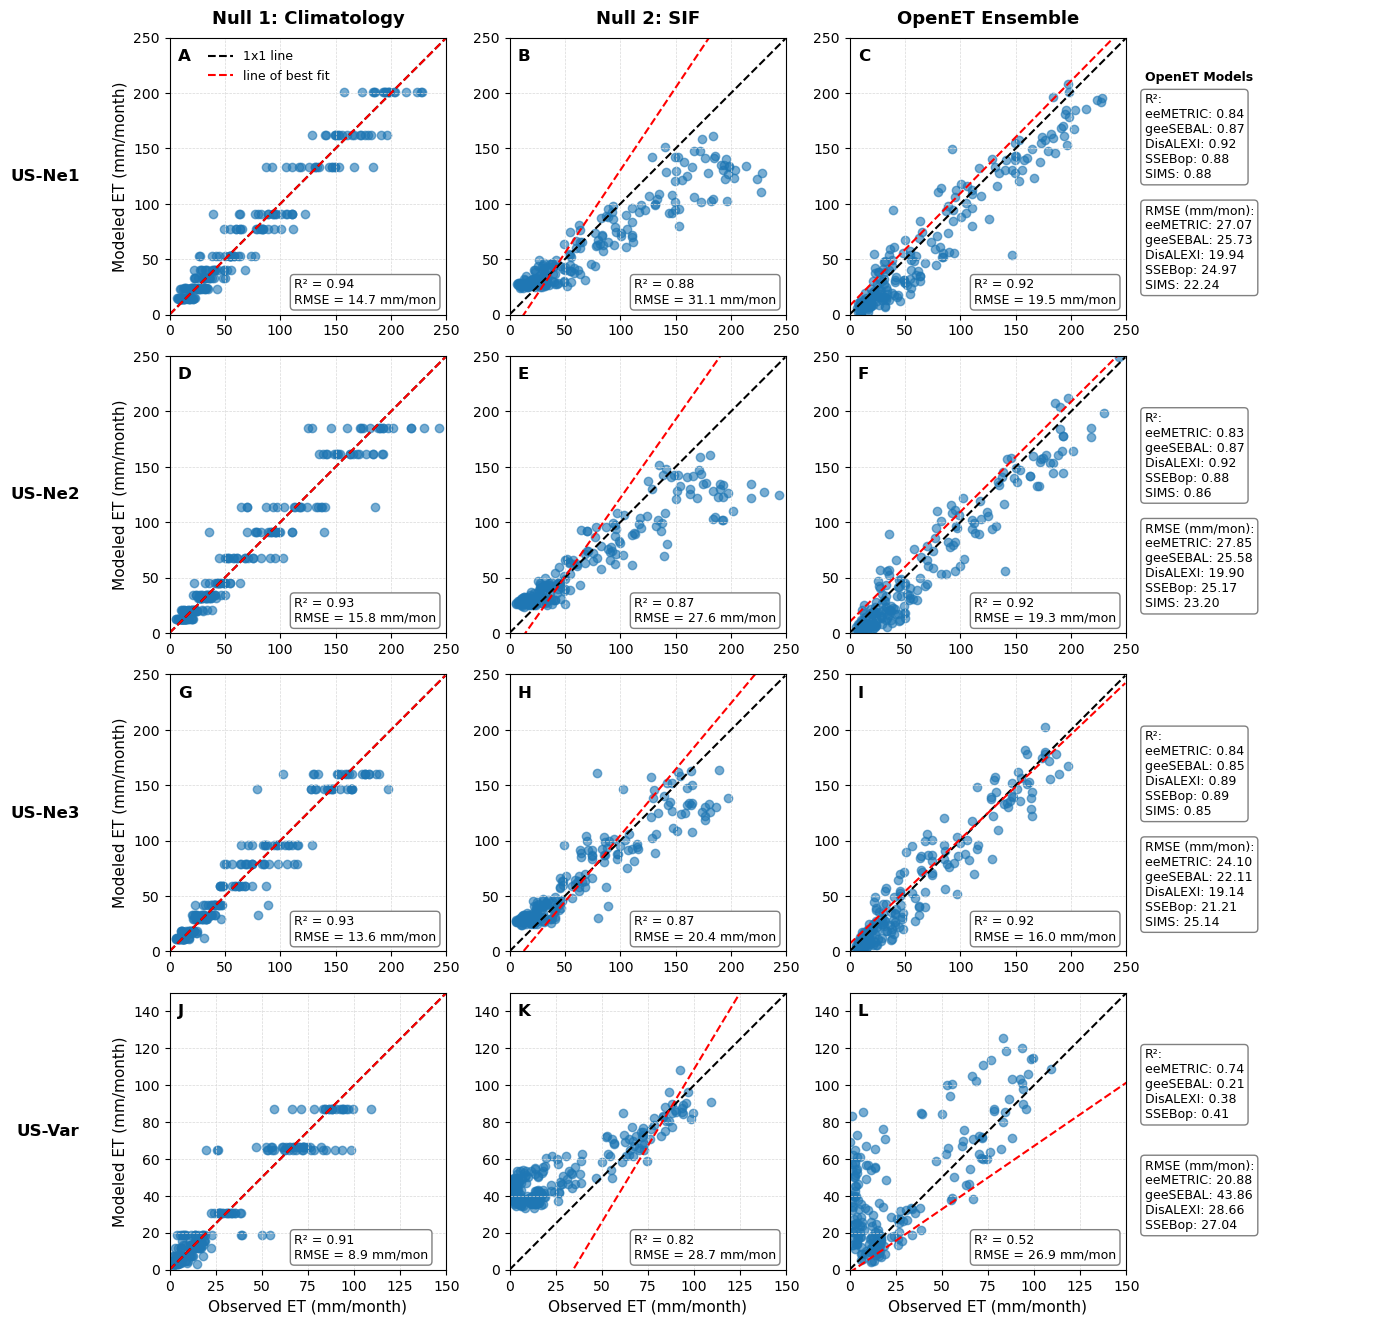

In [13]:
vars = ("Climatology", "SIF_ET", "Ensemble")
col_headers = ["Null 1: Climatology", "Null 2: SIF", "OpenET Ensemble"]
mod_vars = ('eeMETRIC', 'geeSEBAL', 'DisALEXI', 'SSEBop', 'PT_JPL', 'SIMS')

axis_values = {
    "Ne": (0, 250, 0, 250, 10, 0.005, 163.33),
    "Var": (0, 150, 0, 150, 6, 0.10, 98)
}

# Panel letters sized to figure shape
n_rows, n_cols = len(fp), len(vars)
letters = np.array(list(string.ascii_uppercase[: n_rows * n_cols])).reshape(n_rows, n_cols)

# --- Figure + GridSpec: 3 equal data cols + 1 slim annotation col on the right ---
fig = plt.figure(figsize=(len(vars)*5, len(fp)*4))
gs = gridspec.GridSpec(
    nrows=n_rows,
    ncols=4,                       # 3 data columns + 1 annotation column
    figure=fig,
    width_ratios=[1, 1, 1, 0.65],  # tune last value to widen/narrow the side column
    wspace=0.25, hspace=0.15
)

axes = np.empty((n_rows, n_cols), dtype=object)
ann_axes = [None]*n_rows  # one annotation axis per row

for row_idx, fn in enumerate(fp):
    # create the per-row annotation axis once
    ann_ax = fig.add_subplot(gs[row_idx, 3])
    ann_ax.axis("off")
    ann_axes[row_idx] = ann_ax

    df = pd.read_csv(fn+"_clim.csv", delimiter=',', parse_dates=["Date"])
    df["Date"] = pd.to_datetime(df["Date"])
    stats = pd.read_csv(fn+"_stats.csv", delimiter=',')
    subset = stats[stats["Season"] == "All Months"]

    axis_limits = axis_values["Ne"] if fn in ("US-Ne1", "US-Ne2", "US-Ne3") else axis_values["Var"]

    for col_idx, var in enumerate(vars):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        axes[row_idx, col_idx] = ax

        subset1 = df[["observed_ET", var]].dropna()
        obs = subset1["observed_ET"].values
        y = subset1[var].values.reshape(-1, 1)

        ax.scatter(obs, y, alpha=0.6)
        ax.plot(np.arange(0, 250), np.arange(0, 250), 'k--', label='1x1 line')

        model = LinearRegression().fit(y, obs)
        slope = model.coef_[0]
        intercept = model.intercept_
        line_x = np.arange(0, 250)
        line_y = (line_x * slope) + intercept
        ax.plot(line_x, line_y, 'r--', label='line of best fit')

        ax.set_xlim(axis_limits[0], axis_limits[1])
        ax.set_ylim(axis_limits[2], axis_limits[3])
        ax.grid(True, linestyle="--", linewidth=0.5, color="0.85")

        # Labels: left column gets Y, bottom row gets X
        if col_idx == 0:
            ax.set_ylabel("Modeled ET (mm/month)", fontsize=11)
        if row_idx == n_rows - 1:
            ax.set_xlabel("Observed ET (mm/month)", fontsize=11)
        # ax.set_xlabel("Observed ET (mm/month)", fontsize=11)

        # Panel letter
        ax.text(0.03, 0.96, letters[row_idx, col_idx],
                transform=ax.transAxes, ha="left", va="top",
                fontsize=12, fontweight="bold")

        # Metrics box inside each subplot (compact)
        key = var
        r2_val = subset.loc[subset["Variable"] == key, "R2"]
        rmse_val = subset.loc[subset["Variable"] == key, "RMSE"]
        eq_text = f"y={slope:.2f}x {'+' if intercept>=0 else ''}{intercept:.1e}"

        if not r2_val.empty and not rmse_val.empty:
            # text = f"R² = {r2_val.values[0]:.2f}\nRMSE = {rmse_val.values[0]:.1f} mm/month\n{eq_text}"
            text = f"R² = {r2_val.values[0]:.2f}\nRMSE = {rmse_val.values[0]:.1f} mm/mon"
            ax.text(0.45, 0.03, text, transform=ax.transAxes,
                    fontsize=9, va="bottom", ha="left",
                    bbox=dict(boxstyle="round", fc="w", ec="0.5"))

        # Side boxes for Ensemble column go in the per-row annotation axis (keeps spacing stable)
        if var == "Ensemble":
            r2_lines, rmse_lines = [], []
            for mod in mod_vars:
                r2m = subset.loc[subset["Variable"] == mod, "R2"]
                rmsem = subset.loc[subset["Variable"] == mod, "RMSE"]
                if not r2m.empty and not rmsem.empty:
                    r2_lines.append(f"{mod}: {r2m.values[0]:.2f}")
                    rmse_lines.append(f"{mod}: {rmsem.values[0]:.2f}")

            ytop = 0.80
            if r2_lines:
                if fn == "US-Ne1":
                    ann_ax.text(-0.25, ytop+0.08, "OpenET Models",
                                transform=ann_ax.transAxes, fontsize=9, va='top',fontweight="bold")
                ann_ax.text(-0.25, ytop, "R²:\n" + "\n".join(r2_lines),
                            transform=ann_ax.transAxes, fontsize=9, va='top',
                            bbox=dict(boxstyle="round", fc="w", ec="0.5"))
            ytop -= 0.4  # drop down for the next block (tune if needed)
            if rmse_lines:
                ann_ax.text(-0.25, ytop, "RMSE (mm/mon):\n" + "\n".join(rmse_lines),
                            transform=ann_ax.transAxes, fontsize=9, va='top',
                            bbox=dict(boxstyle="round", fc="w", ec="0.5"))

        # Legend inside US-Ne1 × Ensemble
        if var == "Climatology" and fn == "US-Ne1":
            # ax.legend(loc=[.12, 0.82], edgecolor='0.5', fontsize=9)
            ax.legend(frameon=False, loc=[.12, 0.82], fontsize=9)

# Column headers
for j, hdr in enumerate(col_headers):
    axes[0, j].set_title(hdr, fontsize=13, pad=10, fontweight="bold")

# Row labels (site names) on the far left; leave room on right for annotation column
plt.subplots_adjust(left=0.15, right=0.95)
for i, fn in enumerate(fp):
    pos = axes[i, 0].get_position()
    ymid = 0.5 * (pos.y0 + pos.y1)
    fig.text(0.09, ymid, fn, ha="right", va="center", fontsize=12, fontweight="bold")

#plt.savefig("FiguresClean/all_months_corr.pdf", bbox_inches="tight")
plt.show()

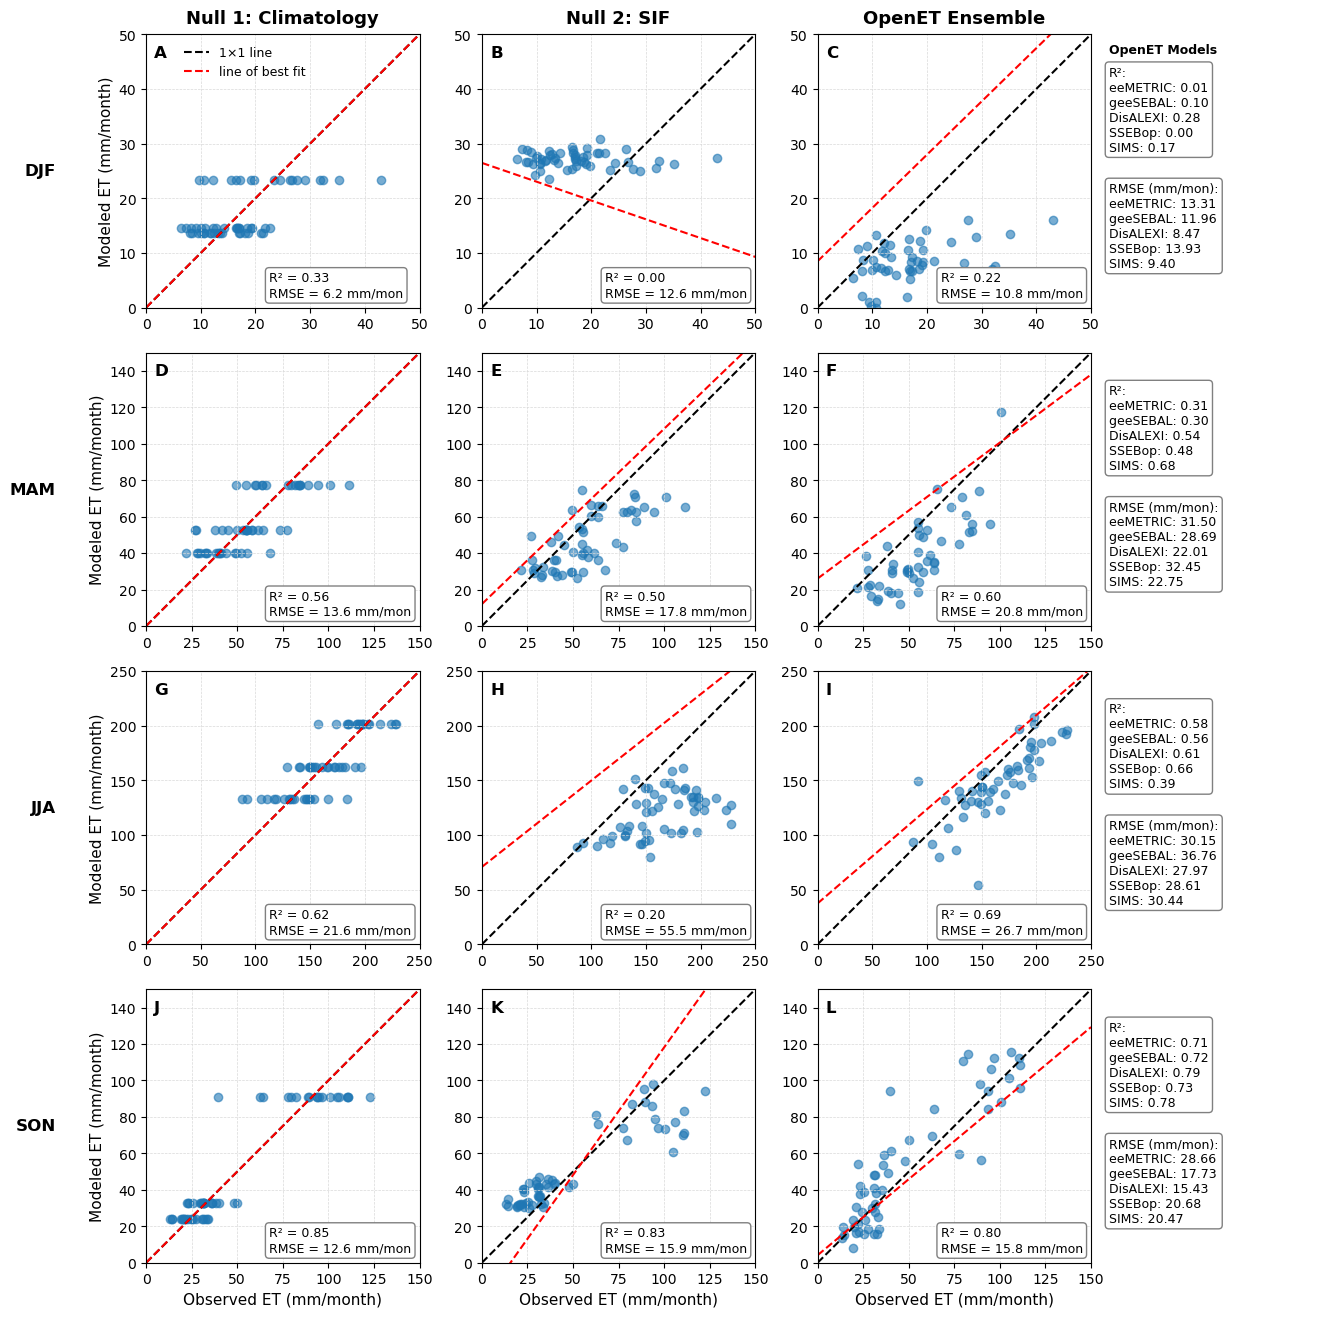

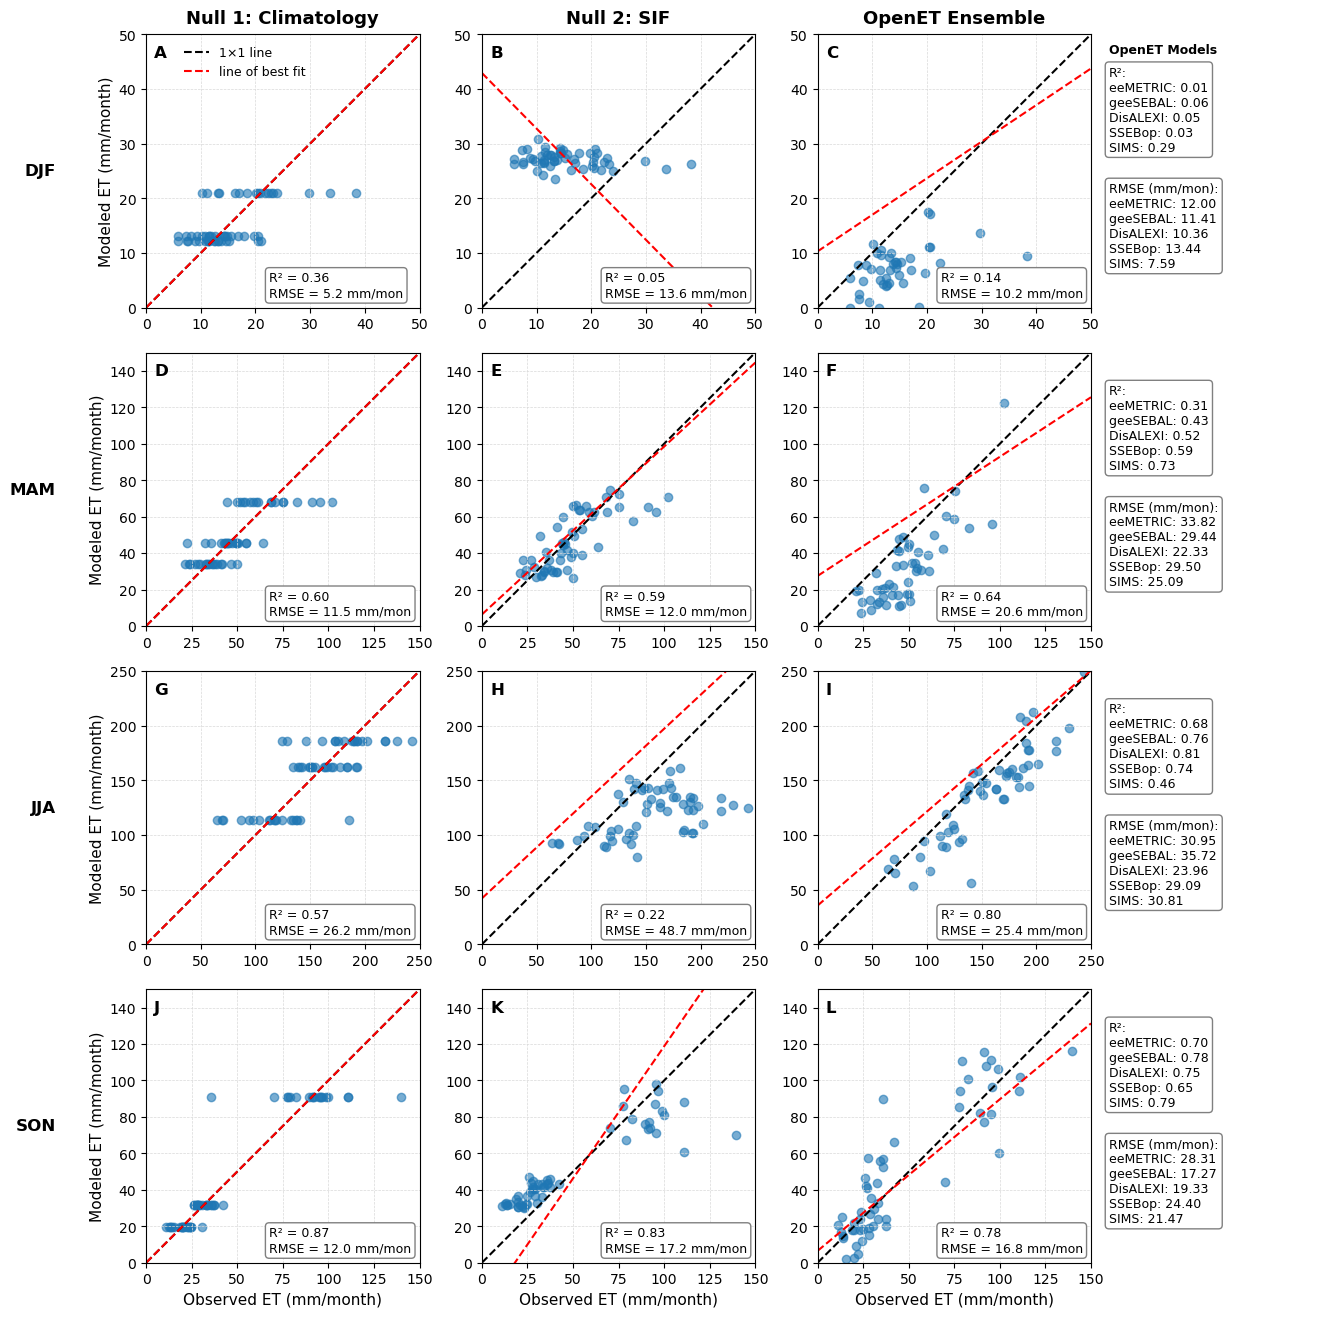

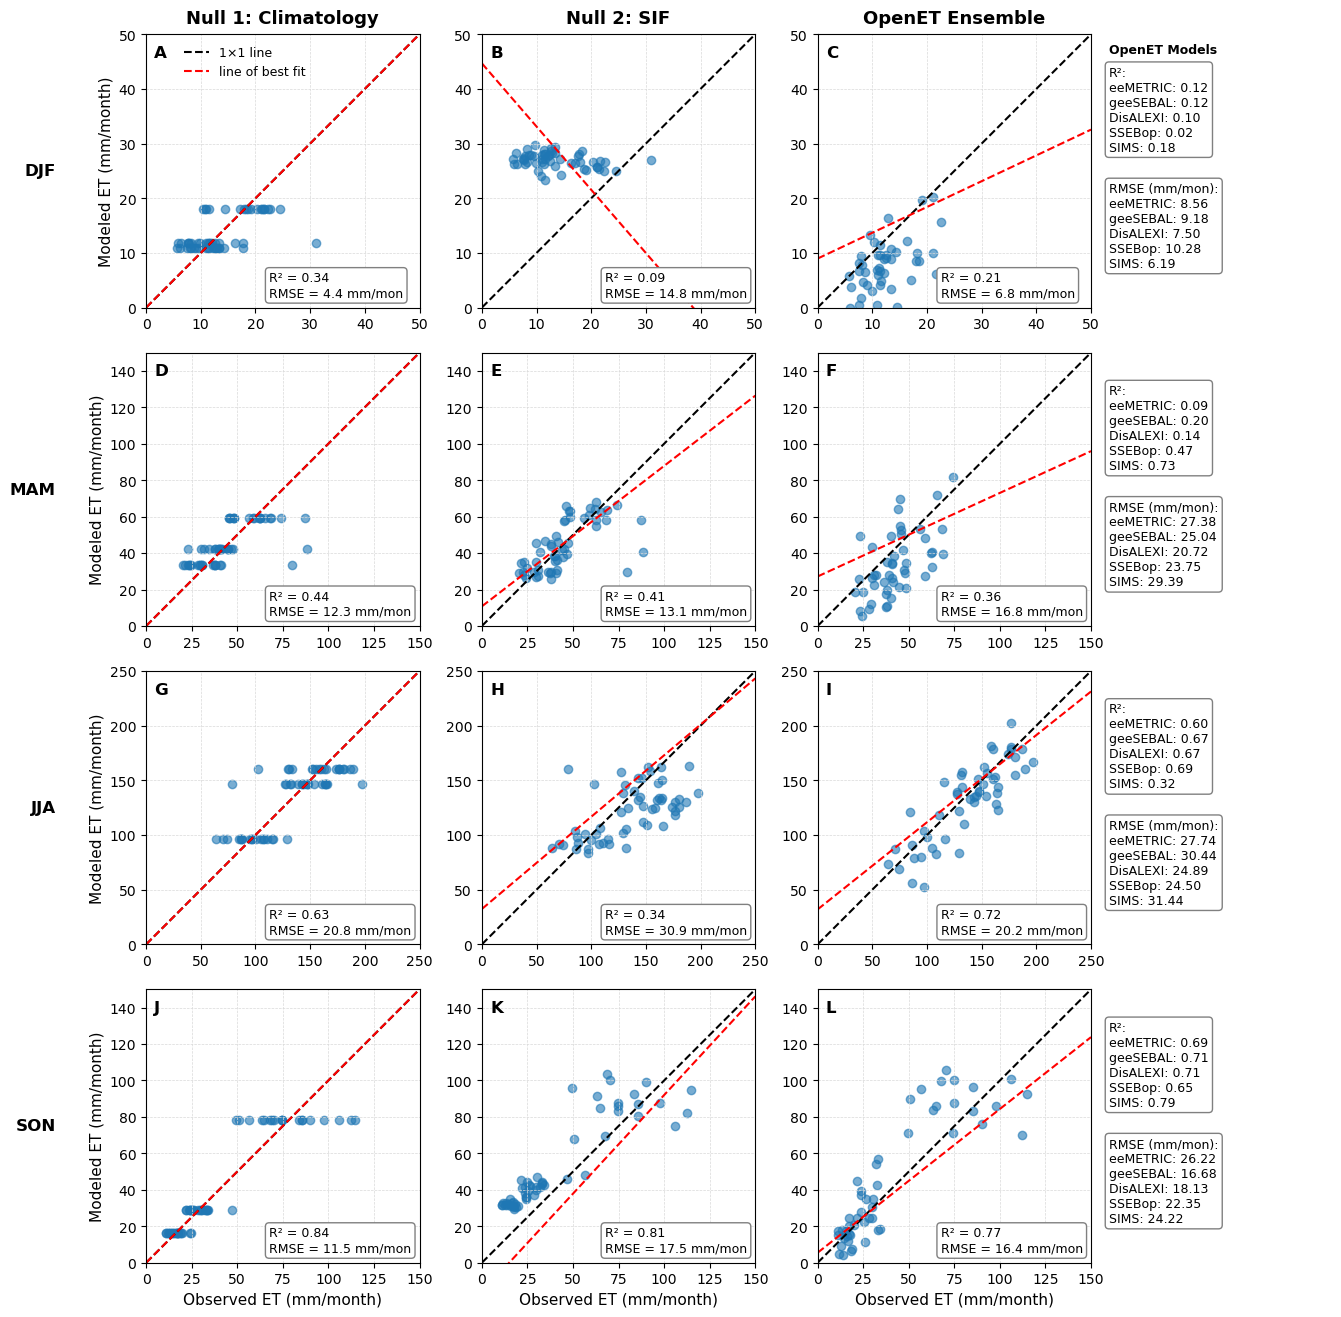

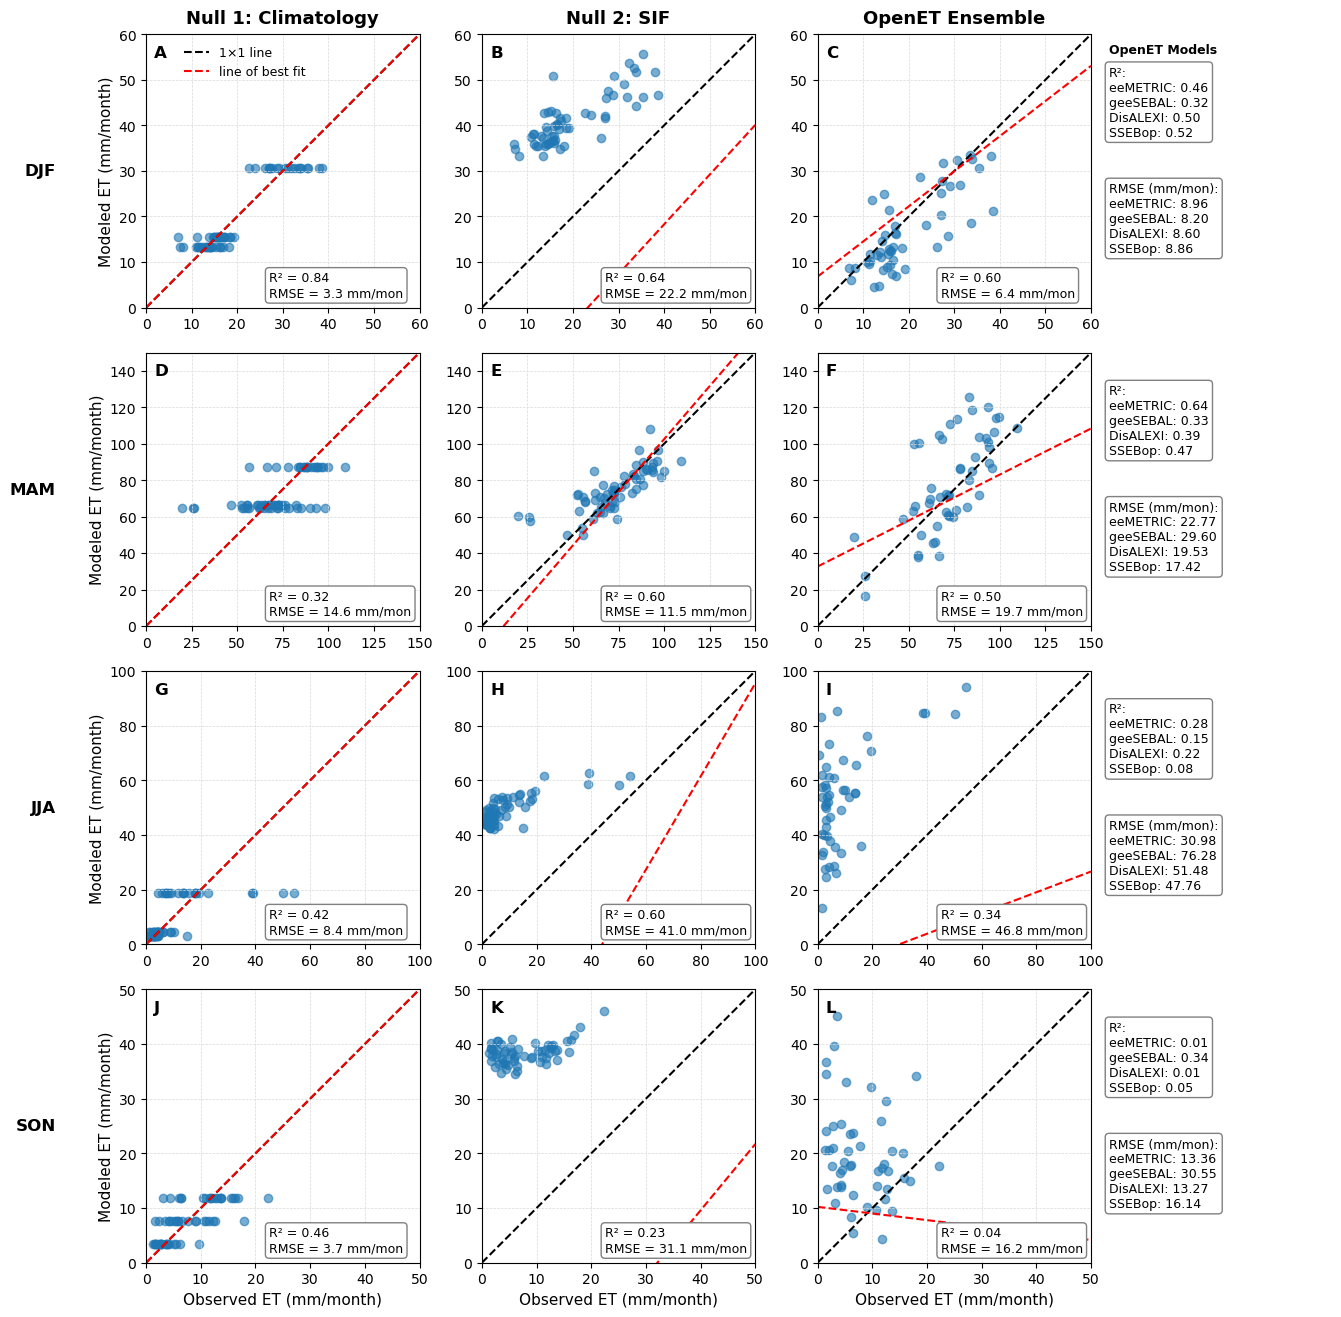

In [9]:
# optional cleanup in a cell
if 'max' in globals(): del max
if 'min' in globals(): del min

import string, numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression

plot_vars = ("Climatology", "SIF_ET", "Ensemble")
col_headers = ["Null 1: Climatology", "Null 2: SIF", "OpenET Ensemble"]
mod_vars = ('eeMETRIC', 'geeSEBAL', 'DisALEXI', 'SSEBop', 'PT_JPL', 'SIMS')

# Per-season axis limits (x_min, x_max, y_min, y_max, box_y, box_x_frac, box_x_data)
season_axis1 = {  # US-Ne* sites
    "DJF": (0, 50, 0, 50, 22, 0.05, 9),
    "MAM": (0, 150, 0, 150, 66, 0.05, 27),
    "JJA": (0, 250, 0, 250, 110, 0.05, 45),
    "SON": (0, 150, 0, 150, 65, 0.05, 27),
}
season_axis2 = {  # US-Var
    "DJF": (0, 60, 0, 60, 28, 0.1, 11),
    "MAM": (0, 150, 0, 150, 66, 0.1, 27.5),
    "JJA": (0, 100, 0, 100, 44.5, 0.1, 18.3),
    "SON": (0, 50, 0, 50, 22.3, 0.1, 9.2),
}

for fn in fp:  # one figure per site
    # --- data ---
    df = pd.read_csv(fn + "_clim.csv", delimiter=',', parse_dates=["Date"])
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date")
    stats = pd.read_csv(fn + "_stats.csv", delimiter=',')

    seasons = ["DJF", "MAM", "JJA", "SON"]
    n_rows, n_cols = len(seasons), len(plot_vars)

    # panel letters sized to this figure
    letters = np.array(list(string.ascii_uppercase[: n_rows * n_cols])).reshape(n_rows, n_cols)

    # --- layout: 3 equal data cols + 1 slim annotation col ---
    fig = plt.figure(figsize=(n_cols*5, n_rows*4))
    gs = gridspec.GridSpec(nrows=n_rows, ncols=4, figure=fig,
                           width_ratios=[1, 1, 1, 0.65], wspace=0.25, hspace=0.15)

    axes = np.empty((n_rows, n_cols), dtype=object)
    ann_axes = []

    for r, season in enumerate(seasons):
        # per-row annotation axis
        ann_ax = fig.add_subplot(gs[r, 3]); ann_ax.axis("off"); ann_axes.append(ann_ax)

        # choose seasonal limits by site type
        axis_limits = season_axis2[season] if fn == "US-Var" else season_axis1[season]
        xmin, xmax, ymin, ymax = axis_limits[0], axis_limits[1], axis_limits[2], axis_limits[3]

        season_df = df[df.index.month.isin({"DJF":[12,1,2], "MAM":[3,4,5],
                                            "JJA":[6,7,8], "SON":[9,10,11]}[season])]

        for c, var in enumerate(plot_vars):
            ax = fig.add_subplot(gs[r, c])
            axes[r, c] = ax

            sub = season_df[["observed_ET", var]].dropna()
            if sub.empty:
                ax.axis("off"); continue

            obs = sub["observed_ET"].values
            y = sub[var].values.reshape(-1, 1)

            ax.scatter(obs, y, alpha=0.6)
            # 1×1 line from panel limits
            lo, hi = max(xmin, ymin), min(xmax, ymax)
            xx = np.linspace(lo, hi, 200)
            ax.plot(xx, xx, 'k--', label='1×1 line')

            # best-fit line (Observed = a*Model + b)
            model = LinearRegression().fit(y, obs)
            slope, intercept = model.coef_[0], model.intercept_
            yy = slope * xx + intercept
            ax.plot(xx, yy, 'r--', label='line of best fit')

            # limits + square aspect + grid
            ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
            ax.set_aspect('equal', adjustable='box')
            ax.grid(True, linestyle="--", linewidth=0.5, color="0.85")

            # labels only on left column / bottom row
            if c == 0: ax.set_ylabel("Modeled ET (mm/month)", fontsize=11)
            if r == n_rows - 1: ax.set_xlabel("Observed ET (mm/month)", fontsize=11)

            # panel letter (bottom-left)
            ax.text(0.03, 0.96, letters[r, c], transform=ax.transAxes, 
                    ha="left", va="top", fontsize=12, fontweight="bold")

            # small stats box in-panel (R2 / RMSE)
            stats_season = stats[stats["Season"] == season]
            key = var
            r2_val = stats_season.loc[stats_season["Variable"] == key, "R2"]
            rmse_val = stats_season.loc[stats_season["Variable"] == key, "RMSE"]
            if not r2_val.empty and not rmse_val.empty:
                txt = f"R² = {r2_val.values[0]:.2f}\nRMSE = {rmse_val.values[0]:.1f} mm/mon"
                ax.text(0.45, 0.03, txt, transform=ax.transAxes,
                        fontsize=9, va="bottom", ha="left",
                        bbox=dict(boxstyle="round", fc="w", ec="0.5"))

            # legend once (top-left of the first panel)
            if (r == 0) and (c == 0):
                ax.legend(frameon=False, loc=[.12, 0.82], fontsize=9)

            # per-row OpenET model tables in the right annotation column
            if var == "Ensemble":
                r2_lines, rmse_lines = [], []
                for m in mod_vars:
                    r2m = stats_season.loc[stats_season["Variable"] == m, "R2"]
                    rmsem = stats_season.loc[stats_season["Variable"] == m, "RMSE"]
                    if not r2m.empty and not rmsem.empty:
                        r2_lines.append(f"{m}: {r2m.values[0]:.2f}")
                        rmse_lines.append(f"{m}: {rmsem.values[0]:.2f}")

                ytop = 0.88
                if r == 0:  # add heading only on first row of first figure if you prefer
                    ann_ax.text(-0.25, ytop+0.08, "OpenET Models",
                                transform=ann_ax.transAxes, fontsize=9, va='top', fontweight="bold")
                if r2_lines:
                    ann_ax.text(-0.25, ytop, "R²:\n" + "\n".join(r2_lines),
                                transform=ann_ax.transAxes, fontsize=9, va='top',
                                bbox=dict(boxstyle="round", fc="w", ec="0.5"))
                if rmse_lines:
                    ann_ax.text(-0.25, ytop-0.42, "RMSE (mm/mon):\n" + "\n".join(rmse_lines),
                                transform=ann_ax.transAxes, fontsize=9, va='top',
                                bbox=dict(boxstyle="round", fc="w", ec="0.5"))

    # column headers (top row)
    for j, hdr in enumerate(col_headers):
        axes[0, j].set_title(hdr, fontsize=13, pad=8, fontweight="bold")

    # row labels: seasons on the far left
    plt.subplots_adjust(left=0.16, right=0.95)
    for i, season in enumerate(seasons):
        pos = axes[i, 0].get_position()
        ymid = 0.5 * (pos.y0 + pos.y1)
        fig.text(0.10, ymid, season, ha="right", va="center",
                 fontsize=12, fontweight="bold")

    # (optional) site name as a small suptitle
    #plt.savefig(f"FiguresClean/{fn}_season_corr.pdf", bbox_inches="tight")
    # plt.close(fig)


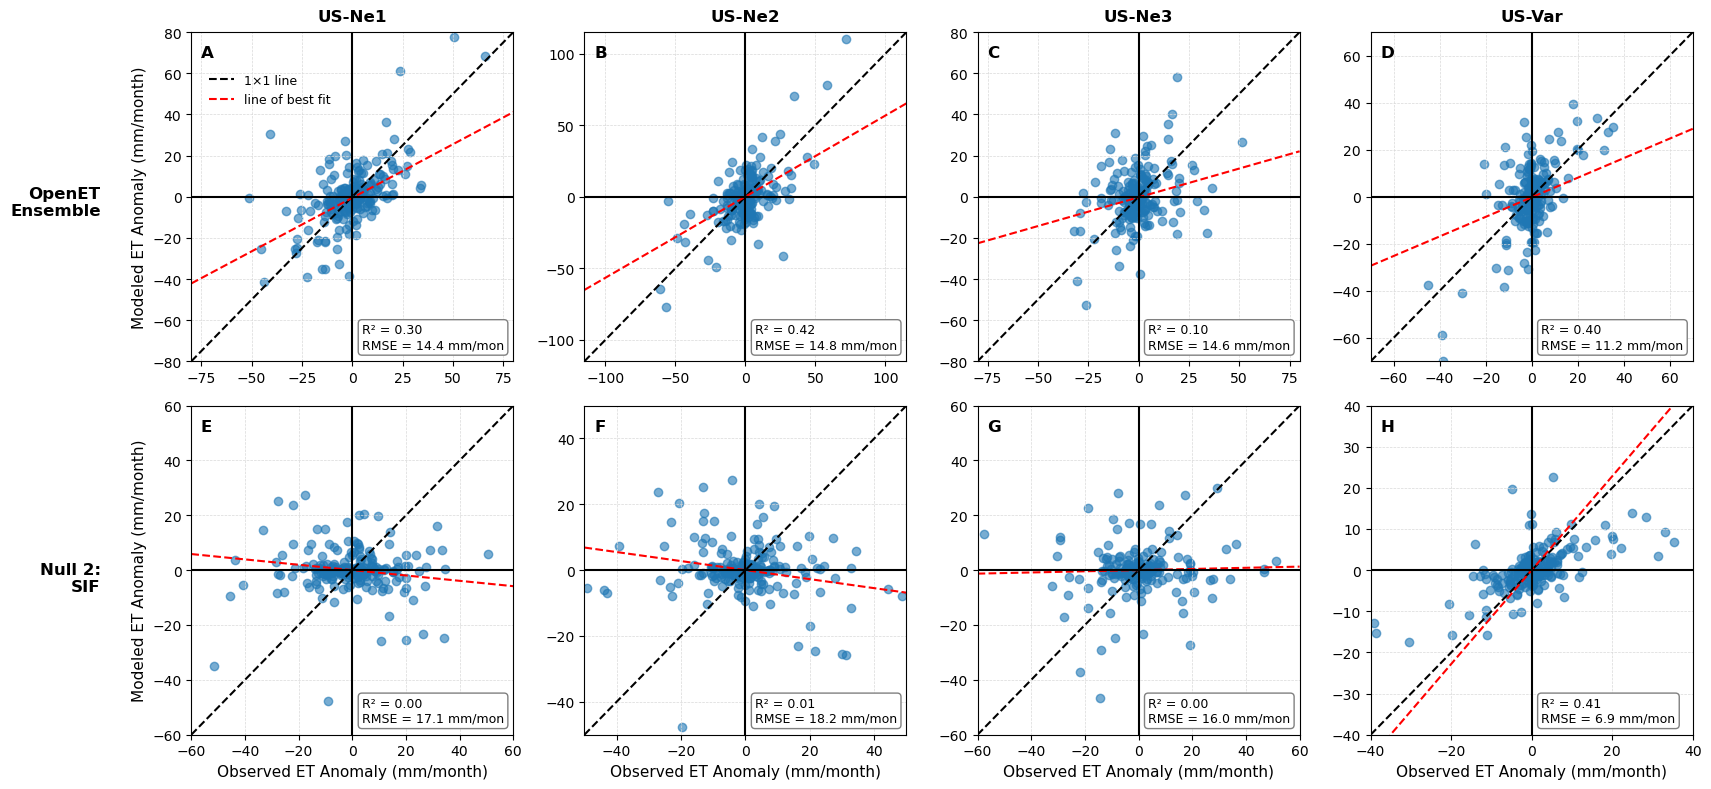

In [7]:
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# rows = models, cols = sites
vars = ("ens_anom", "SIF_anom")          # row order
row_ylabels = {
    "ens_anom": "Modeled ET Anomaly (mm/month)",
    "SIF_anom": "Modeled ET Anomaly (mm/month)",
}

# sites
# fp = ("US-Ne1", "US-Ne2", "US-Ne3", "US-Var")  # assumed defined earlier

# Panel letters for 2x4
letters = np.array(list(string.ascii_uppercase[:2 * len(fp)])).reshape(2, len(fp))

# axis limits & text positions (same structure you used)
axis_values = {
    "Ne":  (-80,  80, -60,  60, 22.5, 16.9, 10,  7),
    "Ne2": (-115,115, -50,  50, 32.3, 14.1, 14.4, 6.25),
    "Var": ( -70, 70, -40,  40, 19.7, 11.3,  8.8, 5),
}

# read stats once
stats_all = pd.read_csv("anom_stats.csv", delimiter=',')

# figure: 2 rows (models) x 4 cols (sites)
fig, axes = plt.subplots(
    nrows=len(vars), ncols=len(fp),
    figsize=(len(fp)*4, len(vars)*4),  # ~4"x4" per panel
    sharex=False, sharey=False
)

for col_idx, fn in enumerate(fp):
    # per-site data
    df = pd.read_csv(f"{fn}_clim.csv", delimiter=',', parse_dates=["Date"])
    df["Date"] = pd.to_datetime(df["Date"])

    stats_sub = stats_all[(stats_all["Site"] == fn) & (stats_all["Season"] == "All Months")]

    # choose axis limits per site
    if fn in ("US-Ne1", "US-Ne3"):
        axis_limits = axis_values["Ne"]
    elif fn == "US-Ne2":
        axis_limits = axis_values["Ne2"]
    else:  # US-Var
        axis_limits = axis_values["Var"]

    # column header (site name) on top row
    axes[0, col_idx].set_title(fn, fontsize=12, pad=8, fontweight="bold")

    for row_idx, var in enumerate(vars):
        ax = axes[row_idx, col_idx]

        subset = df[["obs_anom", var]].dropna()
        if subset.empty:
            ax.axis("off")
            continue

        obs = subset["obs_anom"].values
        y = subset[var].values.reshape(-1, 1)

        # scatter
        ax.scatter(obs, y, alpha=0.6)

        # 1×1 line using appropriate limits for each row/model
        if var == "SIF_anom":
            xmin, xmax = axis_limits[2], axis_limits[3]
            ymin, ymax = xmin, xmax
        else:  # ens_anom
            xmin, xmax = axis_limits[0], axis_limits[1]
            ymin, ymax = xmin, xmax

        xx = np.linspace(xmin, xmax, 200)
        ax.plot(xx, xx, 'k--', label='1×1 line')

        # best-fit (Observed = a*Model + b) on anomalies
        model = LinearRegression().fit(y, obs)
        slope = model.coef_[0]
        intercept = model.intercept_
        yy = slope * xx + intercept
        ax.plot(xx, yy, 'r--', label='line of best fit')

        # limits + grid
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.grid(True, linestyle="--", linewidth=0.5, color="0.85")

        # axes labels: left column gets y-label; bottom row gets x-label
        if col_idx == 0:
            ax.set_ylabel(row_ylabels[var], fontsize=11)
        if row_idx == len(vars) - 1:
            ax.set_xlabel("Observed ET Anomaly (mm/month)", fontsize=11)

        # panel letter (bottom-left)
        ax.text(0.03, 0.96, letters[row_idx, col_idx], transform=ax.transAxes, 
            ha="left", va="top", fontsize=12, fontweight="bold")
        # ax.text(0.03, 0.03, letters[row_idx, col_idx],
        #         transform=ax.transAxes, ha="left", va="bottom",
        #         fontsize=12, fontweight="bold")

        # stats text (R², RMSE) pulled from stats_sub
        r2_val = stats_sub.loc[stats_sub["Variable"] == var, "R2"]
        rmse_val = stats_sub.loc[stats_sub["Variable"] == var, "RMSE"]
        if not r2_val.empty and not rmse_val.empty:
            text = f"R² = {r2_val.values[0]:.2f}\nRMSE = {rmse_val.values[0]:.1f} mm/mon"
            # place text near bottom-left inside axes for consistency
            ax.text(0.53, 0.03, text, transform=ax.transAxes,
                    fontsize=9, va="bottom", ha="left",
                    bbox=dict(boxstyle="round", fc="w", ec="0.5"))

        # legend once: top-right of top-left panel (optional)
        if row_idx == 0 and col_idx == 0:
            ax.legend(frameon=False, loc=[.04, 0.76], fontsize=9)

        # axes crosshairs at zero
        ax.axvline(0, color='k', linestyle='-')
        ax.axhline(0, color='k', linestyle='-')

# --- Row labels on the far left; common Y label ---
row_labels = ["OpenET\nEnsemble", "Null 2:\nSIF"]  # row labels on the left
posy = [0.74,0.27]
plt.subplots_adjust(left=0.16, right=0.98)
for r, label in enumerate(row_labels):
    pos = axes[r, 0].get_position()
    ymid = 0.5 * (pos.y0 + pos.y1)
    # row label text
    fig.text(-0.01, posy[r], label, ha="right", va="center",
             fontsize=12, fontweight="bold")
    
fig.tight_layout()
plt.savefig("FiguresClean/all_months_anom_2_4.pdf", bbox_inches="tight")
plt.show()


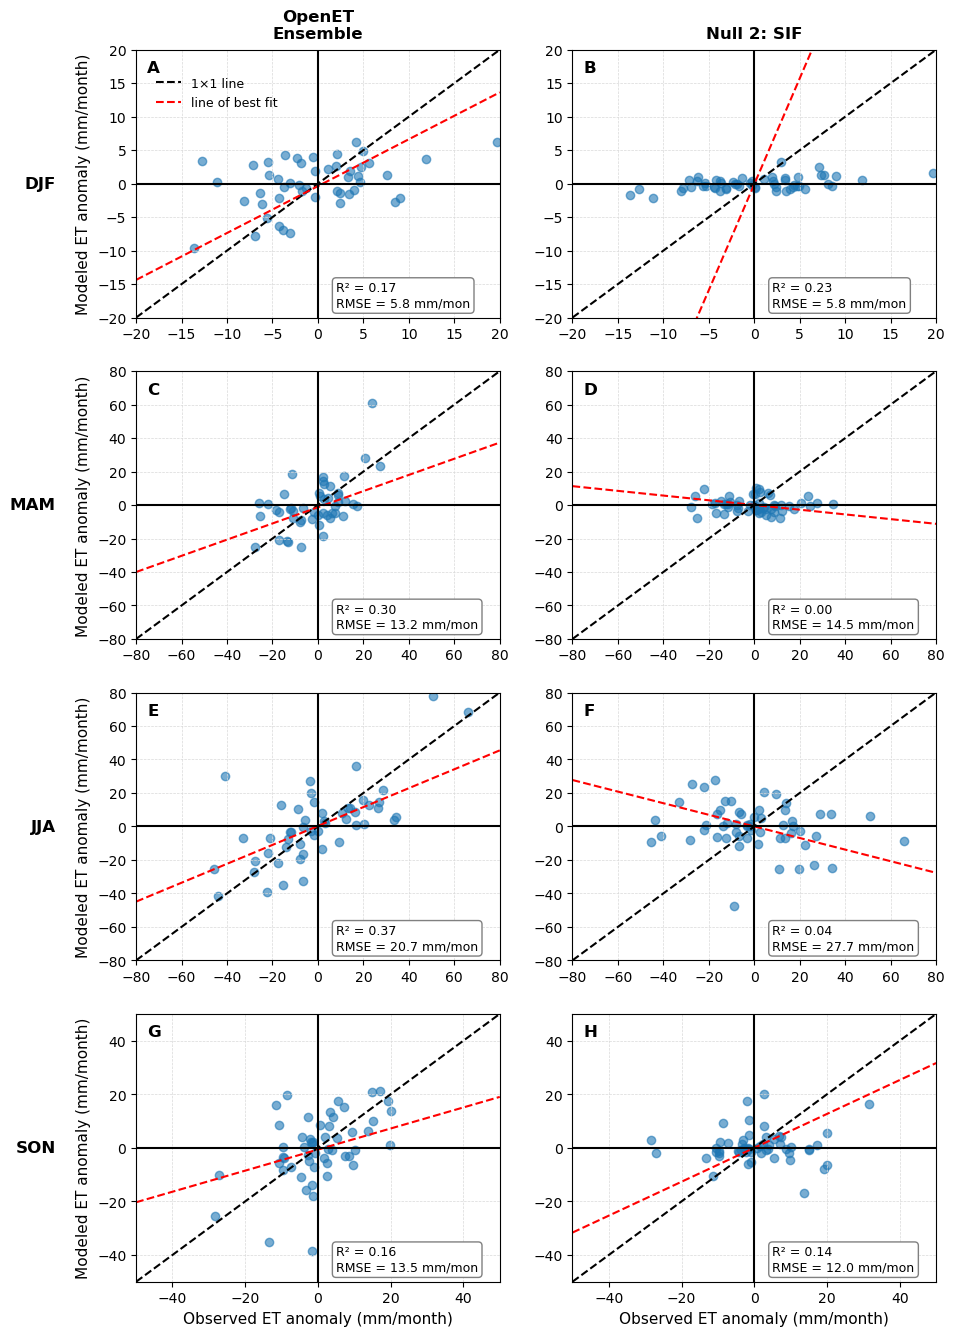

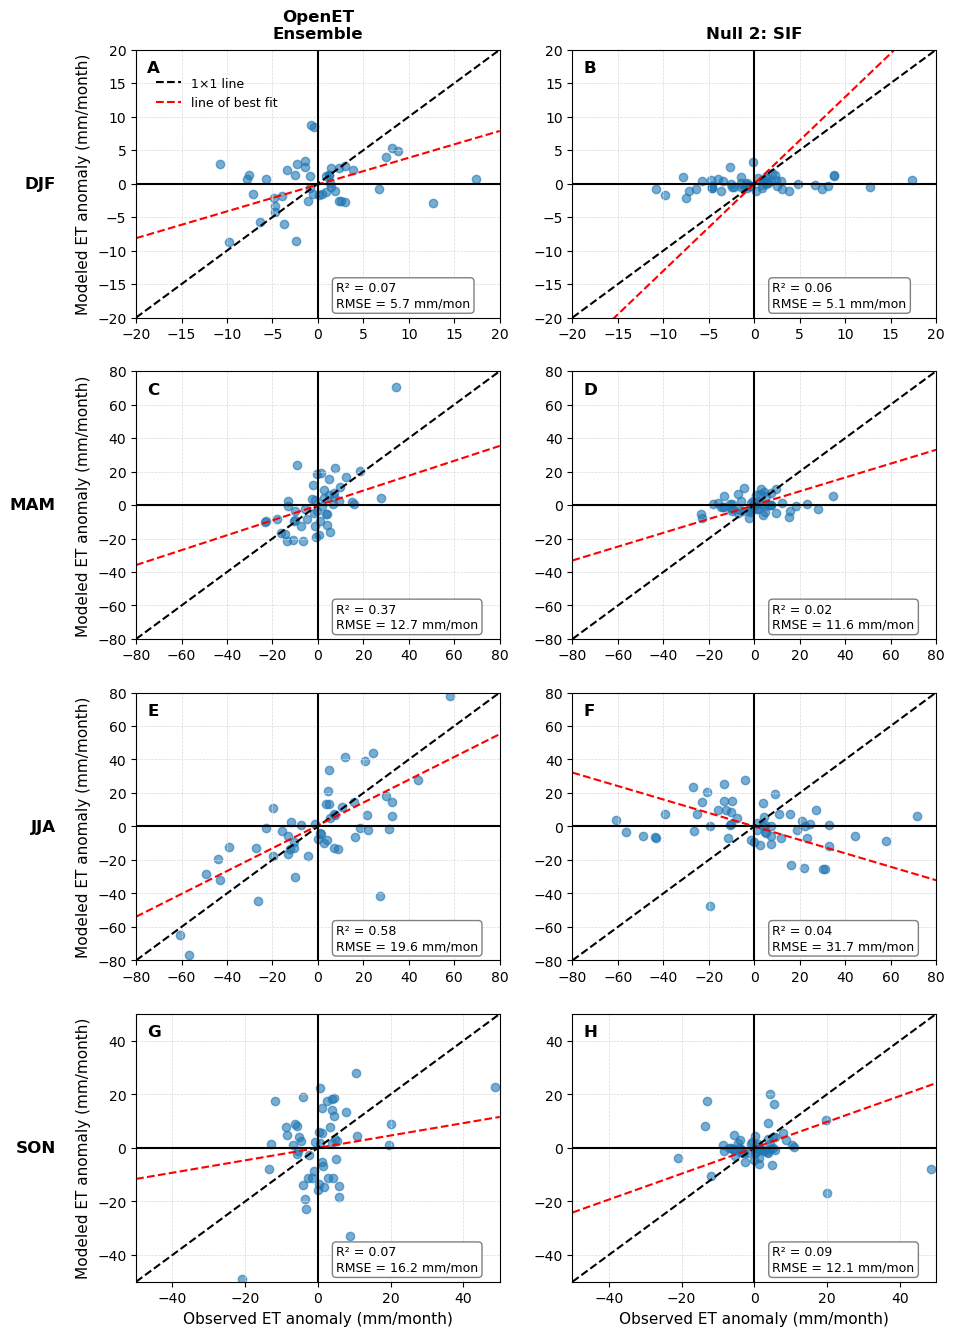

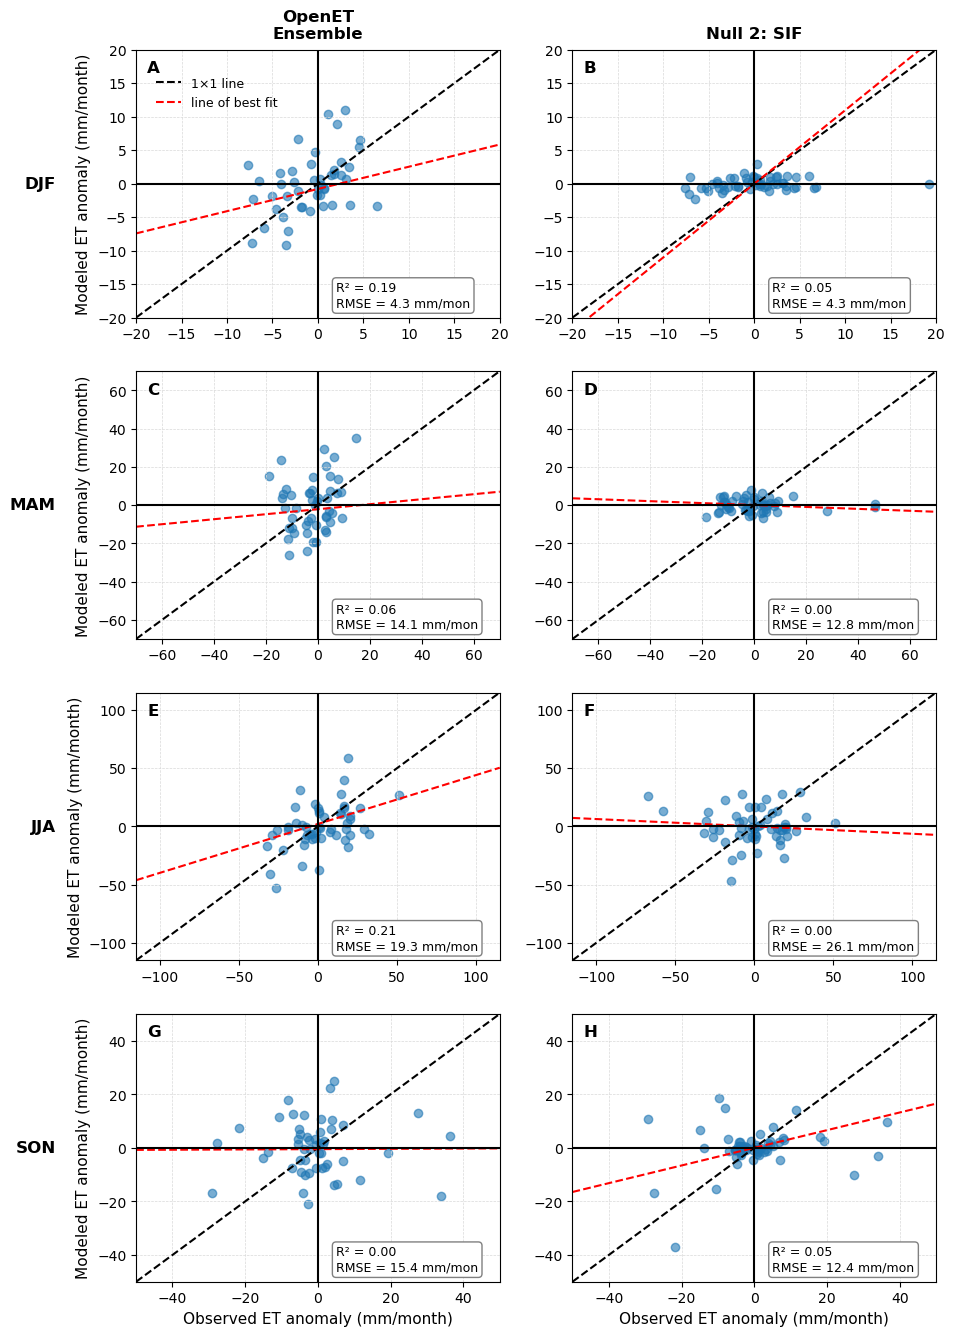

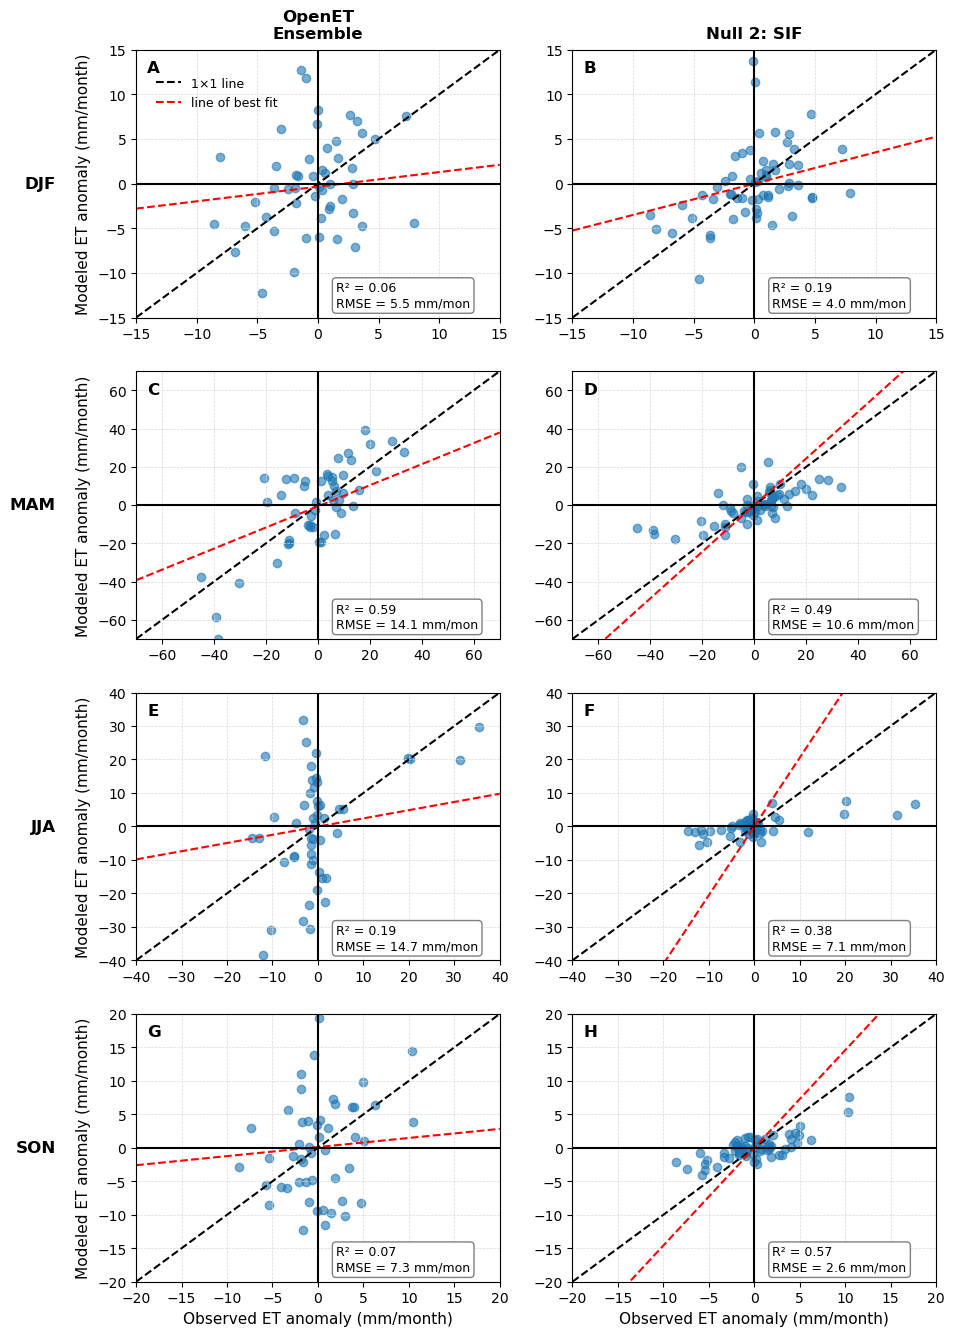

In [8]:
import string, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

plot_vars = ["ens_anom", "SIF_anom"]  # columns = models
col_headers = {"ens_anom": "OpenET\nEnsemble", "SIF_anom": "Null 2: SIF"}  # model names, 2-line style

panel_letters = np.array([
    ['A', 'B'],
    ['C','D'],
    ['E', 'F'],
    ['G', 'H']
])

season_axis1 = {
    "DJF": (-20, 20, 3, 8),
    "MAM": (-80, 80, 10, 32),
    "JJA": (-80, 80, 10, 32),
    "SON": (-50, 50, 5.5, 20)
}
season_axis2 = {
    "DJF": (-20, 20, 7, 8),
    "MAM": (-70, 70, 24.5, 28),
    "JJA": (-115, 115, 40.25, 46),
    "SON": (-50, 50,  17.5, 20)
}
season_axis3 = {
    "DJF": (-15, 15, 2, 6),
    "MAM": (-70, 70, 9, 28),
    "JJA": (-40, 40, 5, 16),
    "SON": (-20, 20, 2.7, 8)
}

for i, fn in enumerate(fp):
    df = pd.read_csv(fn + "_clim.csv", delimiter=',', parse_dates=["Date"])
    stats = pd.read_csv("anom_stats.csv", delimiter=',')
    df["Date"] = pd.to_datetime(df["Date"])
    df.set_index("Date", inplace=True)

    season_filters = {
        "DJF": df[df.index.month.isin([12, 1, 2])],
        "MAM": df[df.index.month.isin([3, 4, 5])],
        "JJA": df[df.index.month.isin([6, 7, 8])],
        "SON": df[df.index.month.isin([9, 10, 11])],
    }
    seasons = list(season_filters.keys())
    n_seasons, n_vars = len(seasons), len(plot_vars)
    labels = np.array(list(string.ascii_uppercase[: n_seasons * n_vars])).reshape(n_seasons, n_vars)

    fig, axes = plt.subplots(n_seasons, n_vars, figsize=(n_vars * 5, n_seasons * 4), sharex=False, sharey=False)

    for row_idx, season_name in enumerate(seasons):
        season_df = season_filters[season_name]

        # fix: use elif chain so the else doesn't overwrite US-Ne3
        if fn == "US-Ne3":
            axis_limits = season_axis2[season_name]
        elif fn == "US-Var":
            axis_limits = season_axis3[season_name]
        else:
            axis_limits = season_axis1[season_name]

        for col_idx, var in enumerate(plot_vars):
            ax = axes[row_idx, col_idx]
            subset = season_df[["obs_anom", var]].dropna()
            stats_sub = stats[(stats["Site"] == fn) & (stats["Season"] == season_name)]

            if subset.empty:
                ax.axis("off")
                continue

            obs = subset["obs_anom"].values
            y = subset[var].values.reshape(-1, 1)

            # scatter
            ax.scatter(obs, y, alpha=0.6)

            # 1×1 line using panel’s anomaly limits
            # X range comes from the anomaly limits for that season/site (first two elements)
            xmin, xmax = axis_limits[0], axis_limits[1]
            xx = np.linspace(xmin, xmax, 200)
            ax.plot(xx, xx, 'k--', label='1×1 line')

            # best-fit (Observed = a*Model + b)
            model = LinearRegression().fit(y, obs)
            slope, intercept = model.coef_[0], model.intercept_
            yy = slope * xx + intercept
            ax.plot(xx, yy, 'r--', label='line of best fit')

            # axes, grid
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(xmin, xmax)  # square numeric scale for anomalies
            ax.axvline(0, color='k', linestyle='-')
            ax.axhline(0, color='k', linestyle='-')
            ax.grid(True, linestyle="--", linewidth=0.5, color="0.85")

            # labels: left col = y label; bottom row = x label
            if col_idx == 0:
                ax.set_ylabel("Modeled ET anomaly (mm/month)", fontsize=11)
            if row_idx == n_seasons - 1:
                ax.set_xlabel("Observed ET anomaly (mm/month)", fontsize=11)

            # A) Top-left panel letters:
            ax.text(0.03, 0.96, panel_letters[row_idx, col_idx],
                    transform=ax.transAxes, ha="left", va="top",
                    fontsize=12, fontweight="bold")
            
            # stats box
            r2_val = stats_sub.loc[stats_sub["Variable"] == var, "R2"]
            rmse_val = stats_sub.loc[stats_sub["Variable"] == var, "RMSE"]
            if not r2_val.empty and not rmse_val.empty:
                text = f"R² = {r2_val.values[0]:.2f}\nRMSE = {rmse_val.values[0]:.1f} mm/mon"
                ax.text(0.55, 0.03, text, transform=ax.transAxes,
                        fontsize=9, va="bottom", ha="left",
                        bbox=dict(boxstyle="round", fc="w", ec="0.5"))

            # legend once
            if season_name == "DJF" and var == "ens_anom":
                ax.legend(frameon=False, loc=[.04, 0.76], fontsize=9)

    # --- Column labels (models) on top row, 2-line centered like earlier ---
    for j, var in enumerate(plot_vars):
        axes[0, j].set_title(col_headers[var], fontsize=12, pad=8, fontweight="bold")

    # --- Row labels (seasons) on far left, centered (robust to layout) ---
    plt.subplots_adjust(left=0.18, right=0.98)
    fig.canvas.draw()  # ensure positions are updated
    pad = 0.02
    for r, season in enumerate(seasons):
        pos = axes[r, 0].get_position()
        x = pos.x0 - pad
        y = 0.5 * (pos.y0 + pos.y1)
        fig.text(0.1, y, season, ha="right", va="center",
                 multialignment="center", linespacing=1.1,
                 fontsize=12, fontweight="bold")

    # optional: site name as small suptitle
    # fig.suptitle(fn, y=0.9, fontsize=13, fontweight="bold")

    plt.savefig(f"FiguresClean/{fn}_season_anom.pdf", bbox_inches="tight")
